# Assignment 1: Building Neural Networks for Image Classification

## Overview
Welcome back to Assignment 1! In this assignment, you'll dive into the fascinating realm of deep learning by building and training neural networks for image classification and object detection tasks using the PyTorch framework. You'll work with two popular datasets: MNIST for image classification and CIFAR-100 for object detection. Throughout the assignment, you'll also fine-tune your models to achieve optimal results.

## Part 3: Achieve Best Accuracy
In the final section of the assignment, you'll take your models to the next level by modifying the model and achieving benchmark performance. You'll experiment with different architectures, hyperparameters, learning rates, and optimization techniques to achieve the best possible accuracy for object classification (CIFAR-100). Your journey will involve analyzing the impact of these changes on the models' accuracy and convergence. Feel free to write your own modules, and make changes to starter code to achieve highest possible accuracy. Results are expected to be submitted in the same format as previous sections however.

Note: You can implement one of the AlexNet, ResNet18, ResNet50, or other architectures discussed in class. However, No transfer learning or pretrained models allowed.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f" {torch.cuda.get_device_name(0)}")
# Specify font family to avoid font warnings on Colab
plt.rcParams['font.family'] = 'DejaVu Sans'

 NVIDIA GeForce RTX 2050


In [2]:
from data import get_dataloaders
import neural_network
import trainer
import visualize

In [3]:
# Hyperparameters
# TODO: Experiment with different hyperparameters
batch_size = 128
learning_rate = 0.1
epochs = 80

In [4]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomErasing(p=0.5),
])
 # TODO: note that you want to keep
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
  # TODO

trainloader, testloader = get_dataloaders(
    dataset_name="cifar100", 
    batch_size=batch_size, 
    train_transforms=transform_train, 
    test_transforms=transform_test
)

Files already downloaded and verified
Files already downloaded and verified


In [5]:
# TODO: Initialize the model, loss function, and optimizer
model = neural_network.BetterModel(num_classes=100, in_channels=3)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [6]:
print(model)

BetterModel(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): BasicResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): 

In [7]:
# TODO: Training loop
train_losses, test_losses = trainer.train(
    model, optimizer, criterion, trainloader, testloader, epochs, device, scheduler
)

Epoch 1/80 - Train Loss: 4.133110677494722
Epoch 1/80 - Test Loss: 3.878580902196184
Epoch 1/80 - Test Accuracy: 12.65%
Epoch 2/80 - Train Loss: 3.734368933436206
Epoch 2/80 - Test Loss: 3.581700315958337
Epoch 2/80 - Test Accuracy: 19.49%
Epoch 3/80 - Train Loss: 3.432730063148167
Epoch 3/80 - Test Loss: 3.296113774746279
Epoch 3/80 - Test Accuracy: 25.69%
Epoch 4/80 - Train Loss: 3.123036385802052
Epoch 4/80 - Test Loss: 3.060122610647467
Epoch 4/80 - Test Accuracy: 30.92%
Epoch 5/80 - Train Loss: 2.873760406928294
Epoch 5/80 - Test Loss: 2.916319623778138
Epoch 5/80 - Test Accuracy: 35.92%
Epoch 6/80 - Train Loss: 2.671090085183263
Epoch 6/80 - Test Loss: 2.5779762750939477
Epoch 6/80 - Test Accuracy: 44.13%
Epoch 7/80 - Train Loss: 2.53243883186594
Epoch 7/80 - Test Loss: 2.6092193368115004
Epoch 7/80 - Test Accuracy: 43.39%
Epoch 8/80 - Train Loss: 2.4205800163776368
Epoch 8/80 - Test Loss: 2.6463078909282443
Epoch 8/80 - Test Accuracy: 43.41%
Epoch 9/80 - Train Loss: 2.3511988012

# Visualize Final Results: Best Model - CIFAR 100

In [8]:
# Evaluate the models
accuracy = trainer.evaluate_accuracy(model, testloader, device)
train_acc = trainer.evaluate_accuracy(model, trainloader, device)

print("C8_epochs_80 Model Test Accuracy:", accuracy)
print("C8_epochs_80 Model Train Accuracy:", train_acc)

C8_epochs_80 Model Test Accuracy: 77.96
C8_epochs_80 Model Train Accuracy: 98.604


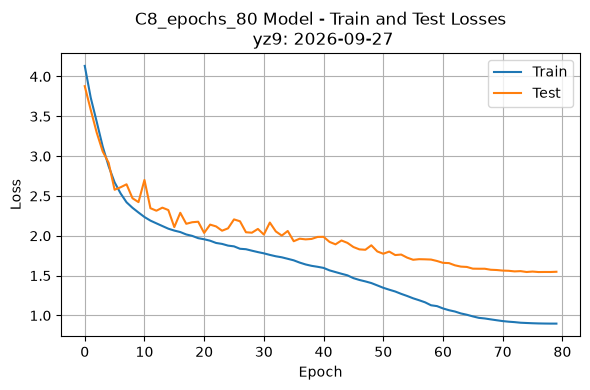

In [9]:
# Plot train and test losses
visualize.visualize_loss(train_losses, test_losses, "C8_epochs_80 Model")

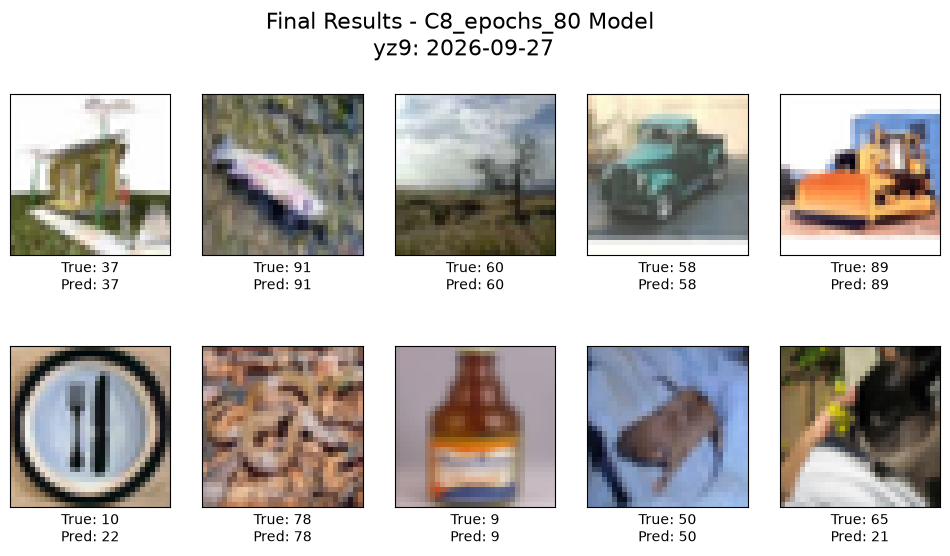

: 

In [ ]:
# Visualize the final results
visualize.visualize_images(model, testloader.dataset, device, "C8_epochs_80 Model")